#  Simple Regression with PyTorch
  Topic: Predicting Flood Water Depth from Rainfall Intensity

Goal: Train a small neural network that learns the relationship between rainfall intensity (mm/hr) and flood water depth (cm).

Steps:
- Generate synthetic data
- Build a Dataset and DataLoader
- Define a neural network model
- Train with a loss function and optimizer
- Evaluate and visualize results

In [39]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Fix random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [40]:
# ── 1. Generate Synthetic Data ────────────────────────────────────────────────
#
# True relationship (unknown to the model):
#   depth = 0.8 * rainfall^1.2 + noise
#
# This mimics a nonlinear rainfall-runoff response.

N = 500                                         # number of samples
rainfall = np.random.uniform(0, 50, N)          # rainfall intensity  [mm/hr]
noise    = np.random.normal(0, 2, N)            # measurement noise   [cm]
depth    = 0.8 * rainfall**1.2 + noise          # flood water depth   [cm]

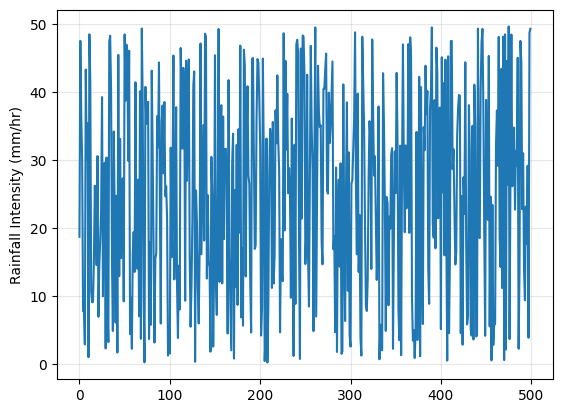

In [41]:
plt.plot(rainfall)
plt.ylabel("Rainfall Intensity (mm/hr)")
plt.grid(alpha=0.3)
plt.show()

In [42]:
# Train / validation / test split  (60 / 20 / 20)
# reshape to (N, 1) for PyTorch compatibility
split = int(0.6 * N)
X_train = rainfall[:split].astype(np.float32).reshape(-1, 1)
y_train = depth[:split].astype(np.float32).reshape(-1, 1)

split_2 = int(0.8 * N)
X_val   = rainfall[split:split_2].astype(np.float32).reshape(-1, 1)
y_val   = depth[split:split_2].astype(np.float32).reshape(-1, 1)

X_test  = rainfall[split_2:].astype(np.float32).reshape(-1, 1)
y_test  = depth[split_2:].astype(np.float32).reshape(-1, 1)

print(f"Training samples   : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")
print(f"Testing  samples   : {len(X_test)}")

Training samples   : 300
Validation samples : 100
Testing  samples   : 100


In [43]:
# Normalize inputs to [0, 1] — always good practice!
x_min = X_train.min()
x_max = X_train.max()

X_train = (X_train - x_min) / (x_max - x_min)
X_val   = (X_val - x_min) / (x_max - x_min)
X_test  = (X_test - x_min) / (x_max - x_min)

# Normalize targets too (helps training stability)
Y_max = y_train.max()
Y_min = y_train.min()

y_train = (y_train - Y_min) / (Y_max - Y_min)
y_val   = (y_val - Y_min) / (Y_max - Y_min)
y_test  = (y_test - Y_min) / (Y_max - Y_min)

print(X_train.max(), X_train.min())
print(y_train.max(), y_train.min())

1.0 0.0
1.0 0.0


In [44]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Fix random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ── 2. Build a PyTorch Dataset and DataLoader ─────────────────────────────────
#
# PyTorch wants data wrapped in a Dataset object so it can shuffle,
# batch, and feed samples to the model automatically.

class FloodDataset(Dataset):
    """Pairs of (rainfall, depth) observations."""

    def __init__(self, X, y):
        # Convert numpy arrays → PyTorch tensors
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)                  # total number of samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]    # one (input, label) pair

train_dataset = FloodDataset(X_train, y_train)
val_dataset   = FloodDataset(X_val,   y_val)
test_dataset  = FloodDataset(X_test,  y_test)

print(test_dataset.X)
# DataLoader handles batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=30, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=10, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=10, shuffle=False)

print(f"Number of training batches  : {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches   : {len(test_loader)}")

tensor([[0.0996],
        [0.9112],
        [0.5078],
        [0.8339],
        [0.3198],
        [0.9040],
        [0.3900],
        [0.0059],
        [0.9140],
        [0.0875],
        [0.3190],
        [0.9594],
        [0.9600],
        [0.5770],
        [0.6363],
        [0.4501],
        [0.2925],
        [0.3285],
        [0.6776],
        [0.7587],
        [0.7985],
        [0.7965],
        [0.0875],
        [0.4968],
        [0.0533],
        [0.5528],
        [0.4431],
        [0.8961],
        [0.3511],
        [0.1137],
        [0.1400],
        [0.7680],
        [0.6225],
        [0.0975],
        [0.0802],
        [0.7065],
        [0.0687],
        [0.8292],
        [0.7119],
        [0.0774],
        [0.0810],
        [0.9965],
        [0.3748],
        [0.3712],
        [0.8200],
        [0.9565],
        [0.9959],
        [0.7597],
        [0.3769],
        [0.0796],
        [0.7838],
        [0.5618],
        [0.4255],
        [0.9150],
        [0.1078],
        [0

In [45]:
# ── 3. Define the Neural Network ──────────────────────────────────────────────

class RainfallDepthNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.LeakyReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

model = RainfallDepthNet()
print(f"\nModel architecture:\n{model}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {sum(p.numel() for p in model.state_dict().values())}")
print(f"Total trainable parameters: {total_params}")



Model architecture:
RainfallDepthNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)
Total parameters: 177
Total trainable parameters: 177


In [46]:
# ── 4. Loss Function and Optimizer ────────────────────────────────────────────
#
# Loss     : Mean Squared Error — penalizes large prediction errors
# Optimizer: Adam — adapts the learning rate automatically

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [47]:
# ── 5. Training Loop ──────────────────────────────────────────────────────────

EPOCHS = 200
train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):

    # ── Training phase ────────────────────────────────────────────────────────
    model.train()                          # tell PyTorch we are training
    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()  # 1. clear old gradients
        prediction = model(X_batch)  # 2. forward pass
        loss = criterion(prediction, y_batch)  # 3. compute loss
        loss.backward()  # 4. backpropagation
        optimizer.step()  # 5. update weights

        running_loss += loss.item() * len(X_batch)

    train_losses.append(running_loss / len(train_dataset))

    # ── Evaluation phase ──────────────────────────────────────────────────────
    model.eval()                           # tell PyTorch we are evaluating
    with torch.no_grad():                   # no gradient tracking needed
        val_loss = 0.0
        for X_batch, y_batch in val_loader:
            preds = model(X_batch)
            val_loss += criterion(preds, y_batch).item() * len(X_batch)
        val_losses.append(val_loss / len(val_dataset))

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS}  |  "
              f"Train Loss: {train_losses[-1]:.4f}  |  "
              f"Val Loss:  {val_losses[-1]:.4f}")

Epoch   1/200  |  Train Loss: 0.7340  |  Val Loss:  0.6520
Epoch  10/200  |  Train Loss: 0.0852  |  Val Loss:  0.0709
Epoch  20/200  |  Train Loss: 0.0190  |  Val Loss:  0.0176
Epoch  30/200  |  Train Loss: 0.0048  |  Val Loss:  0.0044
Epoch  40/200  |  Train Loss: 0.0012  |  Val Loss:  0.0011
Epoch  50/200  |  Train Loss: 0.0010  |  Val Loss:  0.0009
Epoch  60/200  |  Train Loss: 0.0009  |  Val Loss:  0.0008
Epoch  70/200  |  Train Loss: 0.0008  |  Val Loss:  0.0007
Epoch  80/200  |  Train Loss: 0.0007  |  Val Loss:  0.0006
Epoch  90/200  |  Train Loss: 0.0007  |  Val Loss:  0.0006
Epoch 100/200  |  Train Loss: 0.0006  |  Val Loss:  0.0005
Epoch 110/200  |  Train Loss: 0.0006  |  Val Loss:  0.0005
Epoch 120/200  |  Train Loss: 0.0006  |  Val Loss:  0.0005
Epoch 130/200  |  Train Loss: 0.0006  |  Val Loss:  0.0005
Epoch 140/200  |  Train Loss: 0.0006  |  Val Loss:  0.0005
Epoch 150/200  |  Train Loss: 0.0006  |  Val Loss:  0.0005
Epoch 160/200  |  Train Loss: 0.0005  |  Val Loss:  0.00

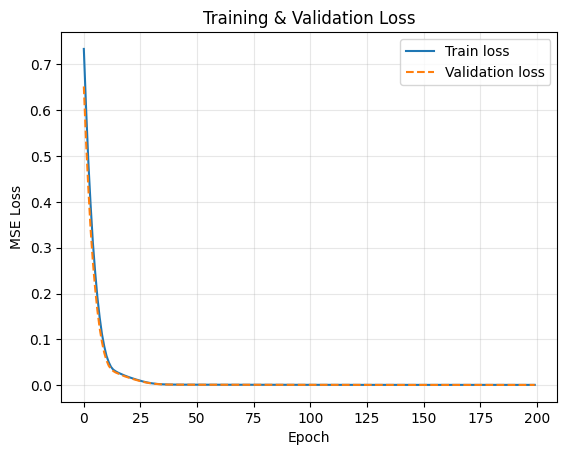

In [48]:
# Loss curves
plt.plot(train_losses, label="Train loss", color="#1f77b4")
plt.plot(val_losses,  label="Validation loss",  color="#ff7f0e", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(alpha=0.3)


In [49]:
preds = []
model.eval()
with torch.no_grad():
    test_loss = 0.0
    for X_batch, y_batch in test_loader:
        pred = model(X_batch)  # shape: (batch_size, 1)

        # move to CPU, remove last dim, convert to 1D numpy
        preds.append(pred.squeeze(-1).cpu().numpy())

        test_loss += criterion(pred, y_batch).item() * len(X_batch)

    test_loss /= len(test_dataset)

# Final shape: (num_test_samples,)
preds = np.concatenate(preds, axis=0)

y_pred = preds  * (Y_max - Y_min) + Y_min
y_gt  = y_test * (Y_max - Y_min) + Y_min

In [50]:
print(Y_min, Y_max)

-2.797722 87.99562


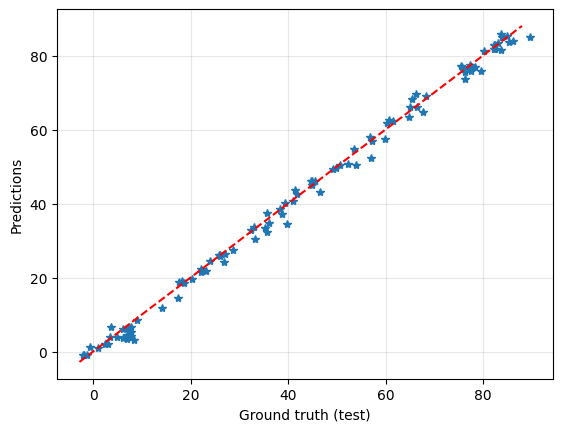

In [51]:
# Scatter plot of predictions vs. ground truth
plt.plot(y_gt, y_pred, '*')
plt.plot([Y_min, Y_max], [Y_min, Y_max], color="r", linestyle="--")
plt.xlabel("Ground truth (test)")
plt.ylabel("Predictions")
plt.grid(alpha=0.3)
plt.show()

In [52]:
# -- 7 Evaluation Metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_gt, y_pred)
r2  = r2_score(y_gt, y_pred)
print(f"Test MSE: {mse:.4f}")
print(f"Test R² : {r2:.4f}")

Test MSE: 3.7981
Test R² : 0.9952


In [ ]:
# Nash-Sutcliffe Efficiency (NSE)
y_obs = np.asarray(y_gt).reshape(-1)
y_sim = np.asarray(y_pred).reshape(-1)

den = np.sum((y_obs - np.mean(y_obs)) ** 2)
num = np.sum((y_obs - y_sim) ** 2)

nse = 1 - (num / den) if den != 0 else np.nan
print(f"Test NSE: {nse:.4f}")